In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/multiple_linear_regression_dataset.csv")

df.head()


,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [ ]:

data = df.values

X = data[:, :-1]
y = data[:, -1]

y = y.reshape(-1, 1)


In [ ]:

X = (X - X.mean(axis=0)) / X.std(axis=0)


In [ ]:

X = np.hstack((np.ones((X.shape[0], 1)), X))


In [ ]:
np.random.seed(42)

weights = np.random.randn(X.shape[1], 1)
learning_rate = 0.01
epochs = 1000


In [ ]:
losses = []

for epoch in range(epochs):

    y_pred = X @ weights

    error = y - y_pred

    weights += learning_rate * X.T @ error / len(X)

    loss = np.mean(error ** 2)
    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, MSE: {loss:.4f}")


Epoch 0, MSE: 1726990102.7512
Epoch 100, MSE: 40878964.5358
Epoch 200, MSE: 5959913.9423
Epoch 300, MSE: 3322055.2945
Epoch 400, MSE: 2355558.4928
Epoch 500, MSE: 1913641.1583
Epoch 600, MSE: 1709376.3044
Epoch 700, MSE: 1614911.0057
Epoch 800, MSE: 1571222.8848
Epoch 900, MSE: 1551018.0541


In [ ]:
print("Final Weights:")
print(weights)


Final Weights:
[[20368.06745495]
 [20367.43247649]
 [ -867.31318495]
 [ 8590.55254125]]


In [ ]:

y_pred = X @ weights

comparison = pd.DataFrame({
    "Actual": y.flatten(),
    "Predicted": y_pred.flatten()
})

comparison.head()


,Actual,Predicted
0,30450,30923.222894
1,35670,34753.490374
2,31580,31107.957242
3,40130,38849.973145
4,47830,48558.749490


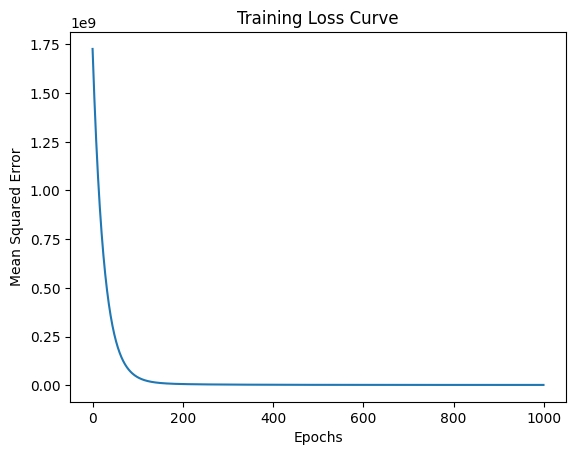

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss Curve")
plt.show()


In [ ]:

mse = np.mean((y - y_pred) ** 2)
print("Mean Squared Error:", mse)


Mean Squared Error: 1541673.746585007


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("R² Score:", r2)


R² Score: 0.9772173202404114
